In [10]:
import pandas as pd

df = pd.read_csv('play_tennis.csv')

x = df.drop(columns=['day', 'play'])
y = df['play']

x.head()

,outlook,temp,humidity,wind
0,Sunny,Hot,High,Weak
1,Sunny,Hot,High,Strong
2,Overcast,Hot,High,Weak
3,Rain,Mild,High,Weak
4,Rain,Cool,Normal,Weak


In [11]:
y

0      No
1      No
2     Yes
3     Yes
4     Yes
5      No
6     Yes
7      No
8     Yes
9     Yes
10    Yes
11    Yes
12    Yes
13     No
Name: play, dtype: object

In [12]:
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder

oe = OrdinalEncoder()
le = LabelEncoder()

X = oe.fit_transform(x)
y = le.fit_transform(y)

<Axes: ylabel='Density'>

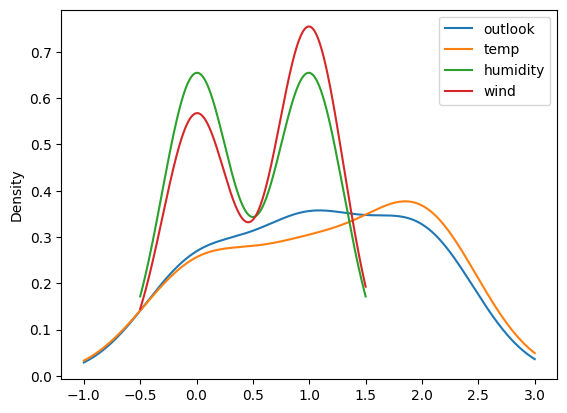

In [13]:
pd.DataFrame(X,columns=x.columns).plot(kind='kde')

In [14]:
#features are categorical, CategoricalNB is a suitable choice.
from sklearn.naive_bayes import CategoricalNB

model = CategoricalNB()

model.fit(X, y)

,"alpha alpha: float, default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"min_categories min_categories: int or array-like of shape (n_features,), default=NoneMinimum number of categories per feature.- integer: Sets the minimum number of categories per feature to `n_categories` for each features.- array-like: shape (n_features,) where `n_categories[i]` holds the minimum number of categories for the ith column of the input.- None (default): Determines the number of categories automatically from the training data... versionadded:: 0.24",None


In [17]:
sample = pd.DataFrame({
    'outlook': ['Sunny'],
    'temp': ['Hot'],
    'humidity': ['High'],
    'wind': ['Weak']
})

sample_encoded = oe.transform(sample)

prediction = model.predict(sample_encoded)

le.inverse_transform(prediction) #convert encoded numerical predictions back into their original categorical labels.


array(['No'], dtype=object)